# Malware Package Classifier — LightGBM

Workflow:
1. Data loading and quality checks
2. Feature engineering (43 static features + 4 engineered ratios)
3. LightGBM baseline
4. Tuned LightGBM with early stopping and threshold optimization
5. Final model and threshold export
6. Baseline models
7. Unified model comparison
8. Bootstrap confidence intervals
9. McNemar's test
10. Family-disjoint evaluation
11. Ablation study
12. Base rate and calibration
13. Best model selection and export

## 1) Load Libraries and Helper Functions

We define a reusable evaluation helper to keep model comparisons consistent (accuracy, malware precision/recall/F1, and PR-AUC).

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

from statsmodels.stats.contingency_tables import mcnemar

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42


def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'malware_precision': precision_score(y_true, y_pred, pos_label=1),
        'malware_recall': recall_score(y_true, y_pred, pos_label=1),
        'malware_f1': f1_score(y_true, y_pred, pos_label=1),
        'pr_auc': average_precision_score(y_true, y_prob),
        'y_pred': y_pred,
    }


print("Libraries loaded successfully!")

Libraries loaded successfully!


In [51]:
df = pd.read_csv('data/dataset-28-04-2026-024308.csv').copy()

df['package_family'] = df['package_name'].str.replace(r'-(\d+(?:\.\d+)*.*)$', '', regex=True)

print(f"Rows: {len(df):,}")
print(f"Benign:  {(df['label'] == 0).sum():,}")
print(f"Malware: {(df['label'] == 1).sum():,}")
print(f"Malware ratio: {(df['label'] == 1).mean() * 100:.2f}%")
print(f"Raw feature columns: {df.shape[1] - 3}")  # minus package_name, ecosystem, label

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])
display(df.head())

Rows: 35,547
Benign:  13,997
Malware: 21,550
Malware ratio: 60.62%
Raw feature columns: 45


Series([], dtype: int64)

,package_name,ecosystem,max_entropy,avg_entropy,label,eval_count,high_entropy_eval_count,exec_count,new_function_count,base64_count,...,dynamic_require_count,dynamic_import_count,eval_string_literal_count,string_literal_entropy_mean,identifier_entropy_mean,avg_function_length,obfuscated_execution_flag,install_time_attack_flag,exfiltration_score,package_family
0,3net.js-0.2.4,NPM,5.101039,4.725404,0,0,0,0,0,0,...,0,0,0,2.766324,2.495632,0.0,0,0,0.00,3net.js
1,4search-0.0.1,NPM,5.413635,4.760083,0,0,0,0,0,0,...,0,0,0,2.199145,2.466756,0.0,0,0,0.00,4search
2,a-driver.js-0.9.8-shadowdom2,NPM,5.419901,4.773957,0,0,0,0,0,0,...,0,0,0,2.431466,2.648410,0.0,0,0,0.00,a-driver.js
3,a-frame-router-templates-0.0.4,NPM,7.943876,5.432943,0,0,0,0,0,0,...,0,0,0,2.737597,2.517284,0.0,0,0,0.09,a-frame-router-templates
4,acc-calc-1.0.2,NPM,5.479960,4.919122,0,0,0,0,0,0,...,0,0,0,1.634586,2.571827,0.0,0,0,0.00,acc-calc


## 3) Feature Engineering and Split Strategy

We use all 43 static features plus 4 engineered interaction ratios. The data is split 72/8/20 (train/val/test). The validation slice drives LightGBM's early stopping; the test set is held out for final evaluation.

In [52]:
X = df.drop(columns=['package_name', 'ecosystem', 'label', 'package_family']).copy()
y = df['label'].copy()

# Engineered interaction features
X['entropy_gap'] = X['max_entropy'] - X['avg_entropy']
X['exec_eval_ratio'] = X['exec_count'] / (X['eval_count'] + 1)
X['network_exec_ratio'] = X['network_call_count'] / (X['exec_count'] + 1)
X['obfuscation_index'] = X['entropy_gap'] * np.log1p(X['base64_count'])

# 80/20 train+val / test split, then carve 10% of train as val for early stopping
X_trainval, X_test, y_trainval, y_test, meta_trainval, meta_test = train_test_split(
    X, y, df[['package_name', 'package_family']],
    test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1, random_state=RANDOM_STATE, stratify=y_trainval,
)

duplicate_rows = int(X.duplicated().sum())
family_overlap = set(meta_trainval['package_family']).intersection(set(meta_test['package_family']))
family_overlap_ratio = (len(family_overlap) / max(1, meta_test['package_family'].nunique())) * 100

# Class imbalance weight for LightGBM
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Duplicate feature rows: {duplicate_rows}")
print(f"Train/Test package-family overlap: {len(family_overlap):,} ({family_overlap_ratio:.2f}% of test families)")
print(f"Total features (incl. engineered): {X_train.shape[1]}")
print(f"scale_pos_weight (benign/malware): {scale_pos_weight:.4f}")
print(f"\nFeature columns ({len(X.columns)}):\n{list(X.columns)}")

Train: 25,593 | Val: 2,844 | Test: 7,110
Duplicate feature rows: 124
Train/Test package-family overlap: 1,387 (23.93% of test families)
Total features (incl. engineered): 48
scale_pos_weight (benign/malware): 0.6495

Feature columns (48):
['max_entropy', 'avg_entropy', 'eval_count', 'high_entropy_eval_count', 'exec_count', 'new_function_count', 'base64_count', 'base64_in_code_count', 'hex_literal_count', 'network_imports', 'network_call_count', 'unique_domains', 'suspicious_tlds_count', 'high_entropy_url_in_network_count', 'child_process_count', 'child_process_exec_count', 'buffer_count', 'os_env_count', 'file_read_count', 'file_write_count', 'sensitive_path_access_count', 'high_entropy_literal_count', 'high_entropy_identifier_count', 'string_literal_count', 'string_literal_entropy_sum', 'identifier_count', 'identifier_entropy_sum', 'max_ast_depth', 'function_count', 'function_node_total', 'dead_code_indicators', 'encoded_payload_chain_count', 'max_string_entropy', 'max_identifier_entr

## 4) LightGBM Baseline

A quick LightGBM run with moderate settings establishes a reference before tuning with early stopping.

In [53]:
baseline_model = lgb.LGBMClassifier(
    objective="binary",
    metric=["binary_logloss", "auc"],
    num_leaves=63,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    verbose=-1,
    random_state=RANDOM_STATE,
    n_estimators=200,
)

baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_results = evaluate_predictions(y_test, baseline_proba, threshold=0.5)

print("LightGBM baseline training complete!")

LightGBM baseline training complete!


In [54]:
print("LightGBM baseline report (threshold = 0.50):")
print(f"Accuracy:          {baseline_results['accuracy'] * 100:.2f}%")
print(f"Malware Precision: {baseline_results['malware_precision']:.4f}")
print(f"Malware Recall:    {baseline_results['malware_recall']:.4f}")
print(f"Malware F1:        {baseline_results['malware_f1']:.4f}")
print(f"PR-AUC:            {baseline_results['pr_auc']:.4f}\n")

print(classification_report(
    y_test,
    baseline_results['y_pred'],
    target_names=['Benign (0)', 'Malware (1)']
))

LightGBM baseline report (threshold = 0.50):
Accuracy:          97.86%
Malware Precision: 0.9777
Malware Recall:    0.9872
Malware F1:        0.9825
PR-AUC:            0.9975

              precision    recall  f1-score   support

  Benign (0)       0.98      0.97      0.97      2800
 Malware (1)       0.98      0.99      0.98      4310

    accuracy                           0.98      7110
   macro avg       0.98      0.98      0.98      7110
weighted avg       0.98      0.98      0.98      7110



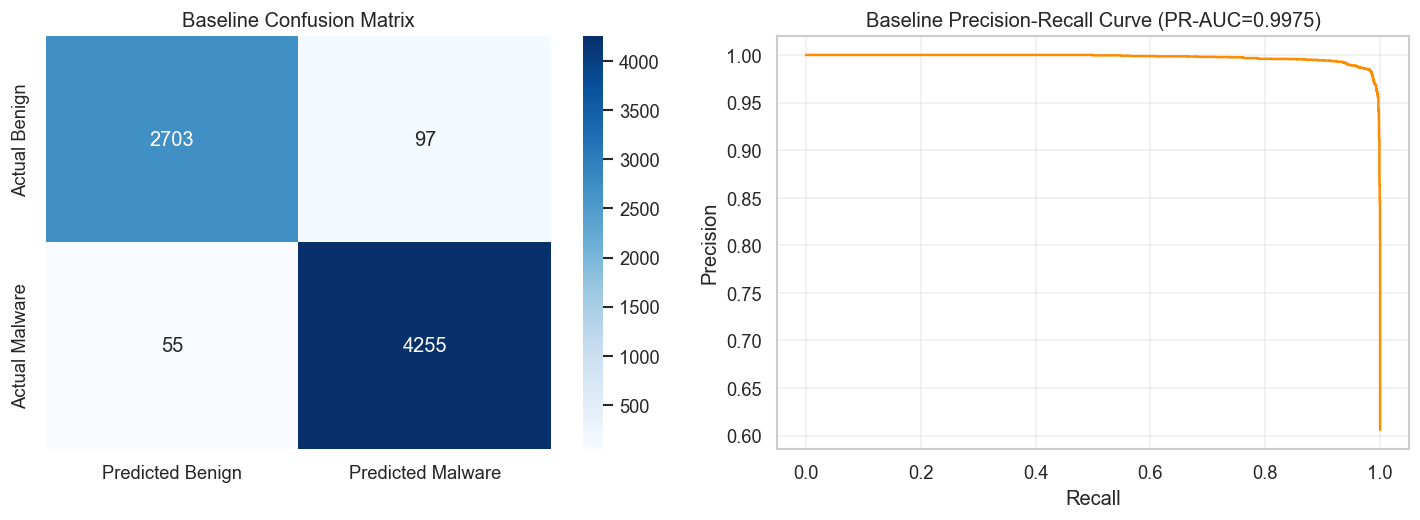

In [55]:
cm = confusion_matrix(y_test, baseline_results['y_pred'])
precision_curve, recall_curve, _ = precision_recall_curve(y_test, baseline_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Benign', 'Predicted Malware'],
    yticklabels=['Actual Benign', 'Actual Malware'],
    ax=axes[0],
 )
axes[0].set_title('Baseline Confusion Matrix')

axes[1].plot(recall_curve, precision_curve, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f"Baseline Precision-Recall Curve (PR-AUC={baseline_results['pr_auc']:.4f})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

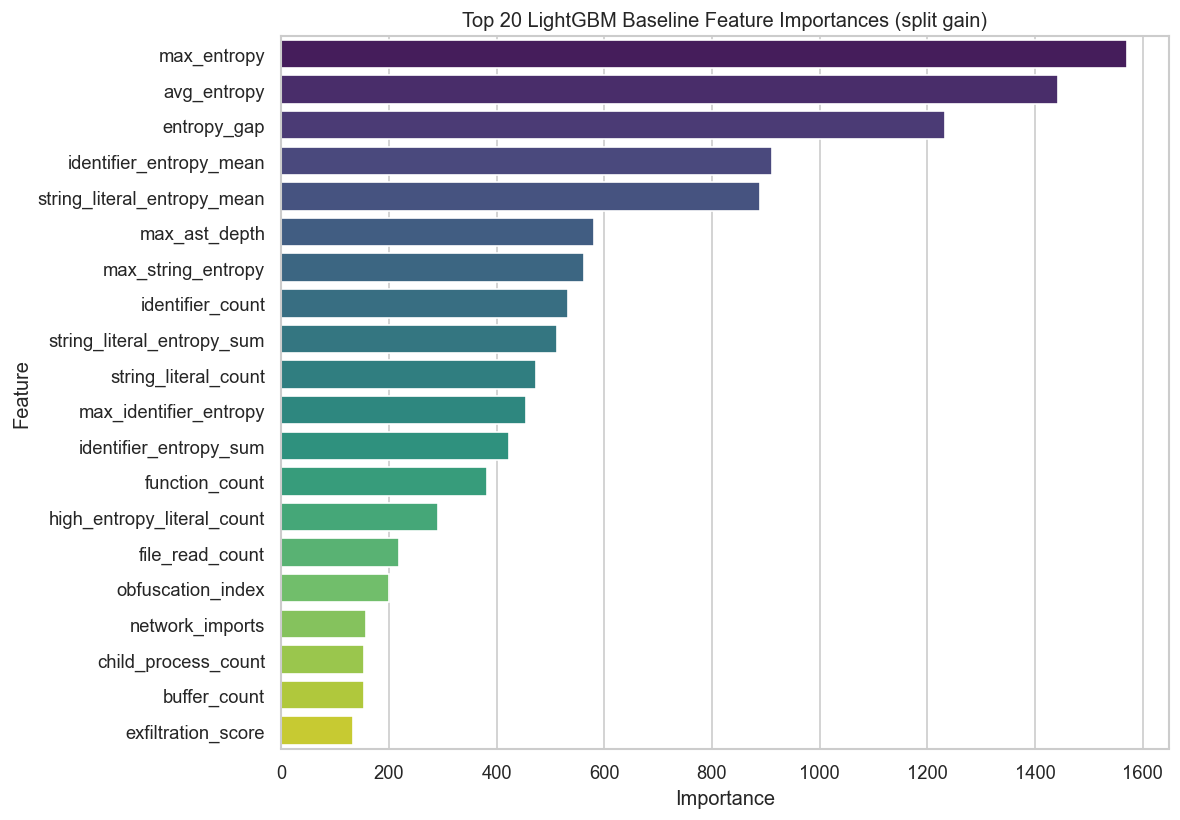

,Feature,Importance
0,max_entropy,1570
1,avg_entropy,1442
2,entropy_gap,1233
3,identifier_entropy_mean,912
4,string_literal_entropy_mean,890
5,max_ast_depth,581
6,max_string_entropy,562
7,identifier_count,533
8,string_literal_entropy_sum,513
9,string_literal_count,473


In [56]:
importances = baseline_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
top_features = feature_df.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    dodge=False,
    palette='viridis',
    legend=False,
)
plt.title('Top 20 LightGBM Baseline Feature Importances (split gain)')
plt.tight_layout()
plt.show()

display(top_features)

## 5) Tuned LightGBM with Early Stopping

We train with more leaves, lower learning rate, bagging, and L1/L2 regularization. Early stopping on the validation set picks the optimal number of trees. The decision threshold is then maximized for malware F1 on the validation set. The final export happens later after all models are compared.

In [57]:
joblib.dump(baseline_model, 'lightgbm_baseline.pkl')
print("Baseline LightGBM saved as 'lightgbm_baseline.pkl'.")

Baseline LightGBM saved as 'lightgbm_baseline.pkl'.


Training tuned LightGBM with early stopping...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0758234	valid_0's auc: 0.996253
[200]	valid_0's binary_logloss: 0.0690622	valid_0's auc: 0.996975
Early stopping, best iteration is:
[166]	valid_0's binary_logloss: 0.0686493	valid_0's auc: 0.996859

Best iteration: 166


,Model,Accuracy,Malware Precision,Malware Recall,Malware F1,PR-AUC,Best Iter
0,LightGBM Baseline @ 0.50,0.9786,0.9777,0.9872,0.9825,0.9975,200
1,LightGBM Tuned @ 0.426,0.9748,0.9708,0.9882,0.9794,0.9972,166



Optimal threshold (from val F1): 0.426340


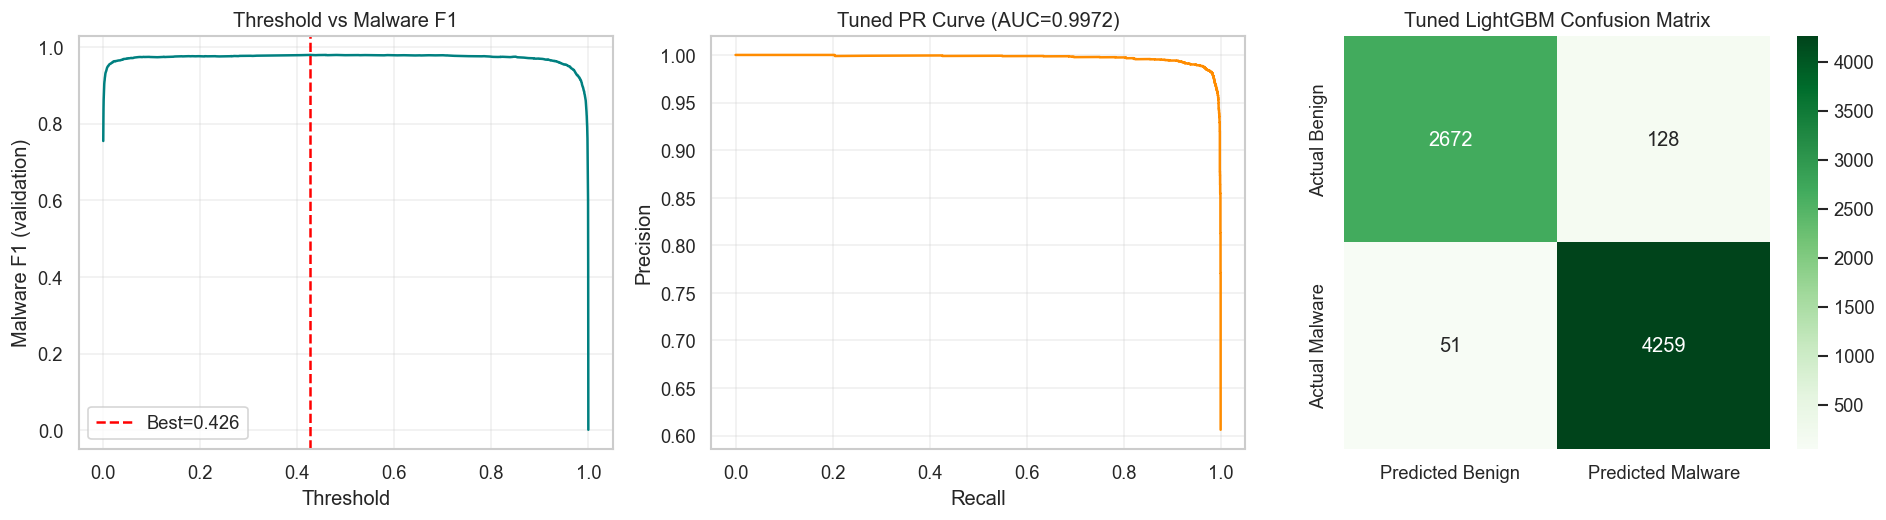

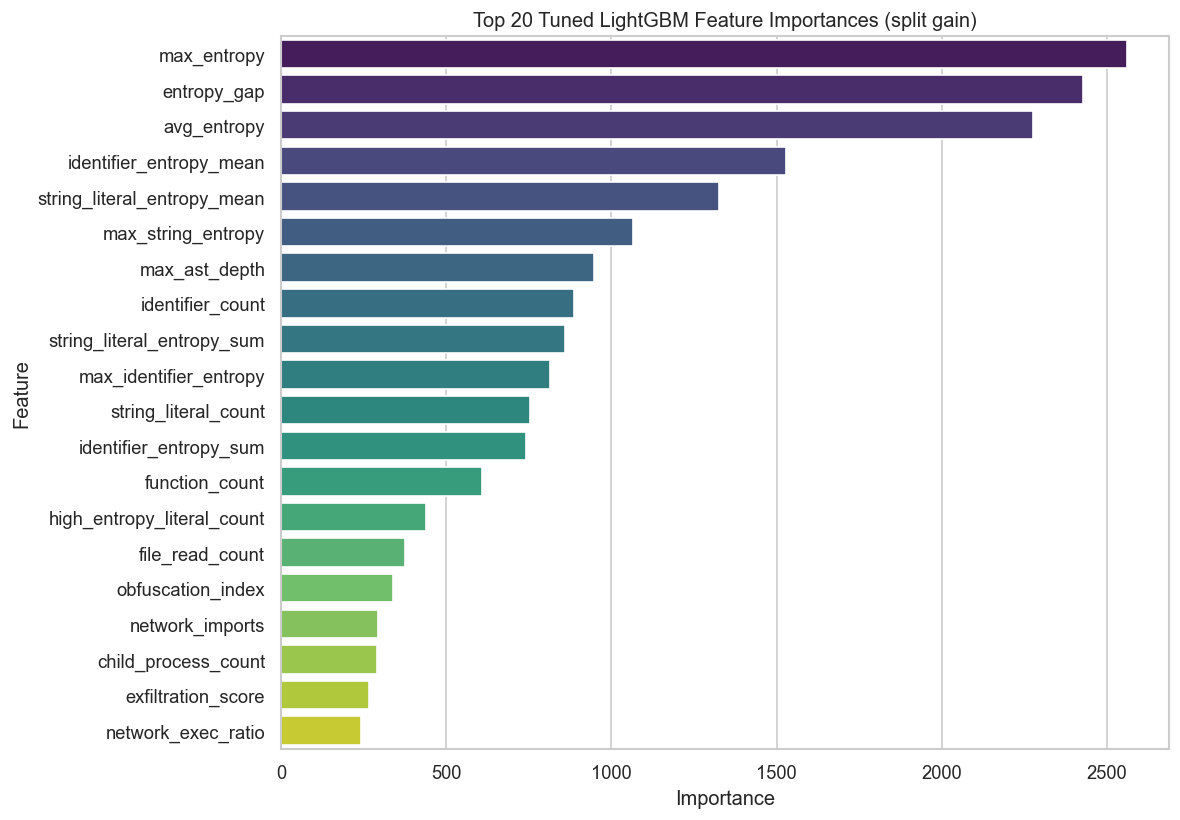

,Feature,Importance
0,max_entropy,2559
1,entropy_gap,2428
2,avg_entropy,2277
3,identifier_entropy_mean,1529
4,string_literal_entropy_mean,1324
5,max_string_entropy,1066
6,max_ast_depth,947
7,identifier_count,886
8,string_literal_entropy_sum,860
9,max_identifier_entropy,815


In [58]:
print("Training tuned LightGBM with early stopping...")

tuned_model = lgb.LGBMClassifier(
    objective="binary",
    metric=["binary_logloss", "auc"],
    num_leaves=127,
    learning_rate=0.05,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    scale_pos_weight=scale_pos_weight,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1,
    random_state=RANDOM_STATE,
    n_estimators=2000,
)

tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)],
)

print(f"\nBest iteration: {tuned_model.best_iteration_}")

# Test-set evaluation at default threshold
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]
tuned_results_default = evaluate_predictions(y_test, tuned_proba, threshold=0.5)

# Threshold optimization: maximize malware F1 on the validation set
val_proba = tuned_model.predict_proba(X_val)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = (2 * precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-12)
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])

tuned_results = evaluate_predictions(y_test, tuned_proba, threshold=best_threshold)

# PR curve on test set (for visualization)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, tuned_proba)

comparison_df = pd.DataFrame([
    {
        'Model': 'LightGBM Baseline @ 0.50',
        'Accuracy': baseline_results['accuracy'],
        'Malware Precision': baseline_results['malware_precision'],
        'Malware Recall': baseline_results['malware_recall'],
        'Malware F1': baseline_results['malware_f1'],
        'PR-AUC': baseline_results['pr_auc'],
        'Best Iter': 200,
    },
    {
        'Model': f"LightGBM Tuned @ {best_threshold:.3f}",
        'Accuracy': tuned_results['accuracy'],
        'Malware Precision': tuned_results['malware_precision'],
        'Malware Recall': tuned_results['malware_recall'],
        'Malware F1': tuned_results['malware_f1'],
        'PR-AUC': tuned_results['pr_auc'],
        'Best Iter': tuned_model.best_iteration_,
    },
])

display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Malware Precision': '{:.4f}',
    'Malware Recall': '{:.4f}',
    'Malware F1': '{:.4f}',
    'PR-AUC': '{:.4f}',
    'Best Iter': '{:.0f}',
}))

print(f"\nOptimal threshold (from val F1): {best_threshold:.6f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(thresholds, f1_scores, color='teal')
axes[0].axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.3f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Malware F1 (validation)')
axes[0].set_title('Threshold vs Malware F1')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(recall_curve, precision_curve, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f"Tuned PR Curve (AUC={tuned_results['pr_auc']:.4f})")
axes[1].grid(alpha=0.3)

tuned_cm = confusion_matrix(y_test, tuned_results['y_pred'])
sns.heatmap(
    tuned_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Benign', 'Predicted Malware'],
    yticklabels=['Actual Benign', 'Actual Malware'],
    ax=axes[2],
)
axes[2].set_title('Tuned LightGBM Confusion Matrix')

plt.tight_layout()
plt.show()

# Tuned feature importances
fi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tuned_model.feature_importances_,
}).sort_values('Importance', ascending=False).head(20).reset_index(drop=True)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', dodge=False, palette='viridis', legend=False)
plt.title('Top 20 Tuned LightGBM Feature Importances (split gain)')
plt.tight_layout()
plt.show()

display(fi_df)

## 6) Baseline Models

Train Logistic Regression, Decision Tree, and Random Forest on the same split. Thresholds are tuned on the validation set using the same precision-recall F1 sweep as LightGBM, then each model is evaluated on the held-out test set.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

baseline_configs = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=15,
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,
        max_depth=20,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

baseline_model_results = {}

for name, clf in baseline_configs.items():
    clf.fit(X_train, y_train)
    val_proba_bl = clf.predict_proba(X_val)[:, 1]
    test_proba_bl = clf.predict_proba(X_test)[:, 1]

    p_, r_, t_ = precision_recall_curve(y_val, val_proba_bl)
    f1_ = (2 * p_[:-1] * r_[:-1]) / (p_[:-1] + r_[:-1] + 1e-12)
    best_t = float(t_[int(np.argmax(f1_))])

    results = evaluate_predictions(y_test, test_proba_bl, threshold=best_t)
    baseline_model_results[name] = {
        'model': clf,
        'proba': test_proba_bl,
        'threshold': best_t,
        'results': results,
    }
    print(
        f"{name:20s}  threshold={best_t:.3f}  F1={results['malware_f1']:.4f}  ",
        f"Prec={results['malware_precision']:.4f}  Rec={results['malware_recall']:.4f}  ",
        f"PR-AUC={results['pr_auc']:.4f}"
    )

LogisticRegression    threshold=0.654  F1=0.9228   Prec=0.9267  Rec=0.9188   PR-AUC=0.9507
DecisionTree          threshold=0.213  F1=0.9717   Prec=0.9633  Rec=0.9803   PR-AUC=0.9469
RandomForest          threshold=0.623  F1=0.9815   Prec=0.9821  Rec=0.9810   PR-AUC=0.9978


## 7) Unified Model Comparison

Collect all five models into one comparison table so the notebook shows the full picture in one place.

In [60]:
all_models = {
    'LogisticRegression': baseline_model_results['LogisticRegression'],
    'DecisionTree': baseline_model_results['DecisionTree'],
    'RandomForest': baseline_model_results['RandomForest'],
    'LightGBM_Baseline': {
        'model': baseline_model,
        'proba': baseline_proba,
        'threshold': 0.5,
        'results': baseline_results,
    },
    'LightGBM_Tuned': {
        'model': tuned_model,
        'proba': tuned_proba,
        'threshold': best_threshold,
        'results': tuned_results,
    },
}

rows = []
for name, entry in all_models.items():
    r = entry['results']
    rows.append({
        'Model': name,
        'Threshold': entry['threshold'],
        'Precision': r['malware_precision'],
        'Recall': r['malware_recall'],
        'F1': r['malware_f1'],
        'PR-AUC': r['pr_auc'],
        'Accuracy': r['accuracy'],
    })

comparison_df = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
display(comparison_df.style.format({
    'Threshold': '{:.3f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'PR-AUC': '{:.4f}',
    'Accuracy': '{:.4f}',
}).highlight_max(subset=['F1', 'PR-AUC', 'Precision', 'Recall'], color='lightgreen'))

,Model,Threshold,Precision,Recall,F1,PR-AUC,Accuracy
0,LightGBM_Baseline,0.500,0.9777,0.9872,0.9825,0.9975,0.9786
1,RandomForest,0.623,0.9821,0.9810,0.9815,0.9978,0.9776
2,LightGBM_Tuned,0.426,0.9708,0.9882,0.9794,0.9972,0.9748
3,DecisionTree,0.213,0.9633,0.9803,0.9717,0.9469,0.9654
4,LogisticRegression,0.654,0.9267,0.9188,0.9228,0.9507,0.9068


## 8) Bootstrap Confidence Intervals

Estimate 95% confidence intervals for F1 and PR-AUC with 1000 bootstrap resamples for every model in the comparison table.

In [61]:
def bootstrap_ci(y_true, y_proba, threshold, n_iter=1000):
    rng = np.random.default_rng(RANDOM_STATE)
    precision_, recall_, f1_, prauc_ = [], [], [], []
    n = len(y_true)
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        r = evaluate_predictions(y_true.iloc[idx], y_proba[idx], threshold=threshold)
        precision_.append(r['malware_precision'])
        recall_.append(r['malware_recall'])
        f1_.append(r['malware_f1'])
        prauc_.append(r['pr_auc'])
    def ci(arr):
        return np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    return {
        'precision_ci': ci(precision_),
        'recall_ci': ci(recall_),
        'f1_ci': ci(f1_),
        'prauc_ci': ci(prauc_),
    }

ci_rows = []
for name, entry in all_models.items():
    ci = bootstrap_ci(y_test, entry['proba'], entry['threshold'])
    ci_rows.append({
        'Model': name,
        'F1': f"{entry['results']['malware_f1']:.4f}",
        'F1 95% CI': f"({ci['f1_ci'][0]:.4f}, {ci['f1_ci'][1]:.4f})",
        'PR-AUC': f"{entry['results']['pr_auc']:.4f}",
        'PR-AUC 95% CI': f"({ci['prauc_ci'][0]:.4f}, {ci['prauc_ci'][1]:.4f})",
    })

display(pd.DataFrame(ci_rows))

,Model,F1,F1 95% CI,PR-AUC,PR-AUC 95% CI
0,LogisticRegression,0.9228,"(0.9169, 0.9284)",0.9507,"(0.9422, 0.9587)"
1,DecisionTree,0.9717,"(0.9681, 0.9749)",0.9469,"(0.9388, 0.9543)"
2,RandomForest,0.9815,"(0.9785, 0.9843)",0.9978,"(0.9972, 0.9985)"
3,LightGBM_Baseline,0.9825,"(0.9796, 0.9851)",0.9975,"(0.9967, 0.9982)"
4,LightGBM_Tuned,0.9794,"(0.9764, 0.9824)",0.9972,"(0.9961, 0.9981)"


## 9) McNemar's Test

Run pairwise McNemar tests to see whether model disagreements are statistically significant.

In [62]:
model_names = list(all_models.keys())
preds = {
    name: (entry['proba'] >= entry['threshold']).astype(int)
    for name, entry in all_models.items()
}

mcnemar_rows = []
for i, a in enumerate(model_names):
    for b in model_names[i+1:]:
        both_correct = ((preds[a] == y_test.values) & (preds[b] == y_test.values)).sum()
        a_right_b_wrong = ((preds[a] == y_test.values) & (preds[b] != y_test.values)).sum()
        a_wrong_b_right = ((preds[a] != y_test.values) & (preds[b] == y_test.values)).sum()
        both_wrong = ((preds[a] != y_test.values) & (preds[b] != y_test.values)).sum()

        table = [[both_correct, a_right_b_wrong],
                 [a_wrong_b_right, both_wrong]]
        result = mcnemar(table, exact=False, correction=True)
        mcnemar_rows.append({
            'Model A': a,
            'Model B': b,
            'p-value': f"{result.pvalue:.4f}",
            'Significant (p<0.05)': 'Yes' if result.pvalue < 0.05 else 'No',
        })

display(pd.DataFrame(mcnemar_rows))

,Model A,Model B,p-value,Significant (p<0.05)
0,LogisticRegression,DecisionTree,0.0000,Yes
1,LogisticRegression,RandomForest,0.0000,Yes
2,LogisticRegression,LightGBM_Baseline,0.0000,Yes
3,LogisticRegression,LightGBM_Tuned,0.0000,Yes
4,DecisionTree,RandomForest,0.0000,Yes
5,DecisionTree,LightGBM_Baseline,0.0000,Yes
6,DecisionTree,LightGBM_Tuned,0.0000,Yes
7,RandomForest,LightGBM_Baseline,0.4941,No
8,RandomForest,LightGBM_Tuned,0.0525,No
9,LightGBM_Baseline,LightGBM_Tuned,0.0005,Yes


## 10) Family-Disjoint Evaluation

Measure how much performance drops when test families are removed from the training-family set.

In [63]:
train_families = set(meta_trainval['package_family'])
disjoint_mask = ~meta_test['package_family'].isin(train_families)

print(f"Full test set:            {len(y_test)}")
print(f"Family-disjoint subset:   {disjoint_mask.sum()}")
print(f"Overlap removed:          {(~disjoint_mask).sum()}\n")

dj_rows = []
for name, entry in all_models.items():
    r_full = entry['results']
    proba_dj = entry['proba'][disjoint_mask]
    y_dj = y_test[disjoint_mask]
    r_dj = evaluate_predictions(y_dj, proba_dj, threshold=entry['threshold'])
    dj_rows.append({
        'Model': name,
        'F1 (full)': r_full['malware_f1'],
        'F1 (disjoint)': r_dj['malware_f1'],
        'F1 drop': r_full['malware_f1'] - r_dj['malware_f1'],
        'PR-AUC (full)': r_full['pr_auc'],
        'PR-AUC (disjoint)': r_dj['pr_auc'],
    })

display(pd.DataFrame(dj_rows).style.format({
    'F1 (full)': '{:.4f}',
    'F1 (disjoint)': '{:.4f}',
    'F1 drop': '{:.4f}',
    'PR-AUC (full)': '{:.4f}',
    'PR-AUC (disjoint)': '{:.4f}',
}).highlight_max(subset=['F1 (disjoint)'], color='lightgreen')
 .highlight_min(subset=['F1 drop'], color='lightblue'))

# Bootstrap 95% CIs on family-disjoint subset
print("Bootstrap 95% CIs on family-disjoint subset (1000 iterations):")
y_dj_boot = y_test[disjoint_mask]
dj_ci_rows = []
for name, entry in all_models.items():
    proba_dj_boot = entry['proba'][disjoint_mask]
    dj_f1 = evaluate_predictions(y_dj_boot, proba_dj_boot, entry['threshold'])['malware_f1']
    ci_dj = bootstrap_ci(y_dj_boot, proba_dj_boot, entry['threshold'])
    dj_ci_rows.append({
        'Model': name,
        'Disjoint F1': f"{dj_f1:.4f}",
        '95% CI': f"({ci_dj['f1_ci'][0]:.4f}, {ci_dj['f1_ci'][1]:.4f})",
    })
print(pd.DataFrame(dj_ci_rows).to_string(index=False))


Full test set:            7110
Family-disjoint subset:   4470
Overlap removed:          2640



,Model,F1 (full),F1 (disjoint),F1 drop,PR-AUC (full),PR-AUC (disjoint)
0,LogisticRegression,0.9228,0.8724,0.0504,0.9507,0.8822
1,DecisionTree,0.9717,0.9424,0.0293,0.9469,0.8817
2,RandomForest,0.9815,0.9664,0.0151,0.9978,0.9947
3,LightGBM_Baseline,0.9825,0.9650,0.0174,0.9975,0.9943
4,LightGBM_Tuned,0.9794,0.9579,0.0215,0.9972,0.9935


Bootstrap 95% CIs on family-disjoint subset (1000 iterations):
             Model Disjoint F1           95% CI
LogisticRegression      0.8724 (0.8609, 0.8839)
      DecisionTree      0.9424 (0.9344, 0.9500)
      RandomForest      0.9664 (0.9601, 0.9723)
 LightGBM_Baseline      0.9650 (0.9589, 0.9714)
    LightGBM_Tuned      0.9579 (0.9509, 0.9646)


## 11) Ablation Study

Retrain the tuned LightGBM model with one feature group removed at a time to identify which feature families matter most.

In [64]:
feature_groups = {
    'entropy_file': [
        'max_entropy', 'avg_entropy', 'entropy_gap',
    ],
    'entropy_code': [
        'max_string_entropy', 'max_identifier_entropy',
        'string_literal_entropy_mean', 'identifier_entropy_mean',
        'string_literal_entropy_sum', 'identifier_entropy_sum',
        'high_entropy_literal_count', 'high_entropy_identifier_count',
    ],
    'ast_structural': [
        'max_ast_depth', 'function_count', 'function_node_total',
        'avg_function_length', 'string_literal_count', 'identifier_count',
    ],
    'behavioral': [
        'network_imports', 'network_call_count', 'unique_domains',
        'child_process_count', 'child_process_exec_count',
        'file_read_count', 'file_write_count', 'os_env_count',
        'sensitive_path_access_count', 'buffer_count',
    ],
    'obfuscation': [
        'eval_count', 'high_entropy_eval_count', 'exec_count',
        'base64_count', 'base64_in_code_count', 'obfuscated_execution_flag',
        'encoded_payload_chain_count', 'obfuscation_index',
    ],
    'engineered': [
        'exfiltration_score', 'exec_eval_ratio',
        'network_exec_ratio', 'install_time_attack_flag',
    ],
}

full_f1 = tuned_results['malware_f1']
full_prauc = tuned_results['pr_auc']

ablation_rows = []
for group_name, cols_to_zero in feature_groups.items():
    X_tr_abl = X_train.copy(); X_tr_abl[cols_to_zero] = 0
    X_val_abl = X_val.copy(); X_val_abl[cols_to_zero] = 0
    X_te_abl = X_test.copy(); X_te_abl[cols_to_zero] = 0

    abl_model = lgb.LGBMClassifier(
        objective='binary',
        num_leaves=127, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        scale_pos_weight=scale_pos_weight,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
        verbose=-1, random_state=RANDOM_STATE, n_estimators=2000,
    )
    abl_model.fit(
        X_tr_abl, y_train,
        eval_set=[(X_val_abl, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )

    abl_proba = abl_model.predict_proba(X_te_abl)[:, 1]
    p_, r_, t_ = precision_recall_curve(y_val, abl_model.predict_proba(X_val_abl)[:, 1])
    f1_ = (2 * p_[:-1] * r_[:-1]) / (p_[:-1] + r_[:-1] + 1e-12)
    abl_thresh = float(t_[int(np.argmax(f1_))])

    abl_res = evaluate_predictions(y_test, abl_proba, threshold=abl_thresh)
    ablation_rows.append({
        'Group removed': group_name,
        'Features zeroed': len(cols_to_zero),
        'F1': abl_res['malware_f1'],
        'F1 drop': full_f1 - abl_res['malware_f1'],
        'PR-AUC': abl_res['pr_auc'],
        'PR-AUC drop': full_prauc - abl_res['pr_auc'],
    })
    print(f"  {group_name:20s}  F1={abl_res['malware_f1']:.4f}  drop={full_f1 - abl_res['malware_f1']:+.4f}")

ablation_df = pd.DataFrame(ablation_rows).sort_values('F1 drop', ascending=False).reset_index(drop=True)
display(ablation_df.style.format({
    'F1': '{:.4f}', 'F1 drop': '{:+.4f}',
    'PR-AUC': '{:.4f}', 'PR-AUC drop': '{:+.4f}',
}).background_gradient(subset=['F1 drop'], cmap='Reds'))

  entropy_file          F1=0.9689  drop=+0.0105
  entropy_code          F1=0.9790  drop=+0.0004
  ast_structural        F1=0.9788  drop=+0.0007
  behavioral            F1=0.9794  drop=+0.0000
  obfuscation           F1=0.9802  drop=-0.0008
  engineered            F1=0.9787  drop=+0.0007


,Group removed,Features zeroed,F1,F1 drop,PR-AUC,PR-AUC drop
0,entropy_file,3,0.9689,+0.0105,0.9900,+0.0072
1,engineered,4,0.9787,+0.0007,0.9972,-0.0000
2,ast_structural,6,0.9788,+0.0007,0.9967,+0.0005
3,entropy_code,8,0.9790,+0.0004,0.9968,+0.0003
4,behavioral,10,0.9794,+0.0000,0.9969,+0.0002
5,obfuscation,8,0.9802,-0.0008,0.9971,+0.0001


## 13) Best Model Selection and Export

Pick the single best model by family-disjoint malware F1, then export that model and its threshold for the microservice.

In [65]:
# Score every model on the family-disjoint subset
scores = {}
for name, entry in all_models.items():
    proba_dj = entry['proba'][disjoint_mask]
    y_dj = y_test[disjoint_mask]
    r = evaluate_predictions(y_dj, proba_dj, threshold=entry['threshold'])
    scores[name] = r['malware_f1']
    print(f"{name:25s}  disjoint F1 = {r['malware_f1']:.4f}")

best_model_name = max(scores, key=scores.get)

# McNemar significance check: top model vs runner-up on disjoint subset
_sorted_models = sorted(scores, key=scores.get, reverse=True)
_top = _sorted_models[0]
_runner = _sorted_models[1]
_preds_top = (all_models[_top]['proba'][disjoint_mask] >= all_models[_top]['threshold']).astype(int)
_preds_runner = (all_models[_runner]['proba'][disjoint_mask] >= all_models[_runner]['threshold']).astype(int)
_y_dj = y_test[disjoint_mask].values
_both_correct = ((_preds_top == _y_dj) & (_preds_runner == _y_dj)).sum()
_top_right = ((_preds_top == _y_dj) & (_preds_runner != _y_dj)).sum()
_runner_right = ((_preds_top != _y_dj) & (_preds_runner == _y_dj)).sum()
_both_wrong = ((_preds_top != _y_dj) & (_preds_runner != _y_dj)).sum()
_mc_table = [[int(_both_correct), int(_top_right)], [int(_runner_right), int(_both_wrong)]]
_mc = mcnemar(_mc_table, exact=False, correction=True)
if _mc.pvalue >= 0.05:
    print(f"WARNING: {_top} is NOT significantly better than {_runner} on the disjoint subset "
          f"(McNemar p={_mc.pvalue:.3f}). Selecting by F1 margin only — document this as a "
          f"non-significant difference in the thesis.")

best_entry = all_models[best_model_name]

print(f"\nSelected for production: {best_model_name}")
print(f"Disjoint F1:             {scores[best_model_name]:.4f}")
print(f"Threshold:               {best_entry['threshold']:.6f}")

feature_columns = list(X_train.columns)

joblib.dump(best_entry['model'], 'lightgbm_model.pkl')
joblib.dump({
    'threshold': float(best_entry['threshold']),
    'feature_columns': feature_columns,
    'model_name': best_model_name,
    'disjoint_f1': scores[best_model_name],
}, 'lightgbm_threshold.pkl')

print(f"\nExported: lightgbm_model.pkl, lightgbm_threshold.pkl")
print(f"Model in production: {best_model_name}")

LogisticRegression         disjoint F1 = 0.8724
DecisionTree               disjoint F1 = 0.9424
RandomForest               disjoint F1 = 0.9664
LightGBM_Baseline          disjoint F1 = 0.9650
LightGBM_Tuned             disjoint F1 = 0.9579

Selected for production: RandomForest
Disjoint F1:             0.9664
Threshold:               0.622994

Exported: lightgbm_model.pkl, lightgbm_threshold.pkl
Model in production: RandomForest


## 12) Base Rate and Calibration

Summarize the tuned model's operating point under different prevalence assumptions and show calibration quality on the held-out test set.

TPR (recall): 0.9810
FPR:          0.0275



,Prevalence,Adjusted Precision,FP per 100k packages
0,0.1%,0.0345,2747
1,0.5%,0.1520,2736
2,1.0%,0.2649,2722
3,5.0%,0.6525,2612



Per-ecosystem breakdown:
  NPM    n=4069  F1=0.9871   Prec=0.9867  Rec=0.9875
  PyPI   n=3041  F1=0.9360   Prec=0.9441  Rec=0.9281


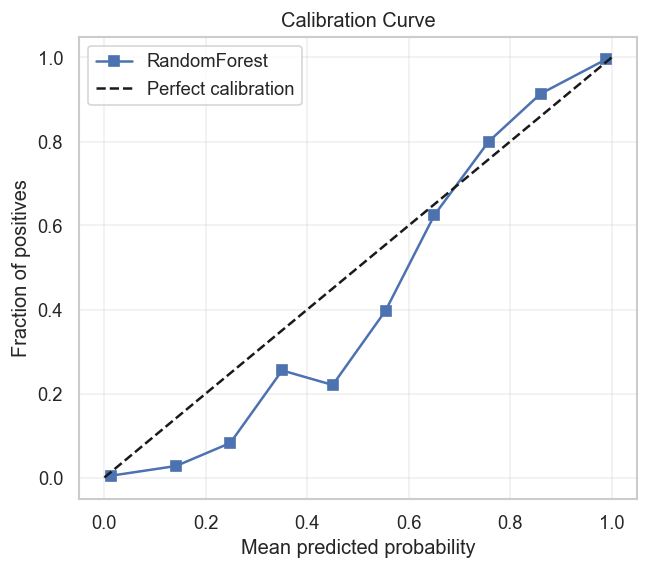

Brier score: 0.0185


In [66]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

production_pred = (best_entry['proba'] >= best_entry['threshold']).astype(int)

cm = confusion_matrix(y_test, production_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"TPR (recall): {tpr:.4f}")
print(f"FPR:          {fpr:.4f}\n")

br_rows = []
for prevalence in [0.001, 0.005, 0.01, 0.05]:
    p_tp = tpr * prevalence
    p_fp = fpr * (1 - prevalence)
    adj_precision = p_tp / (p_tp + p_fp)
    daily_fp = fpr * (1 - prevalence) * 100_000
    br_rows.append({
        'Prevalence': f"{prevalence*100:.1f}%",
        'Adjusted Precision': f"{adj_precision:.4f}",
        'FP per 100k packages': f"{daily_fp:.0f}",
    })
display(pd.DataFrame(br_rows))

print("\nPer-ecosystem breakdown:")
for eco in ['NPM', 'PyPI']:
    mask = df.loc[X_test.index, 'ecosystem'] == eco
    r = evaluate_predictions(y_test[mask], best_entry['proba'][mask], threshold=best_entry['threshold'])
    print(
        f"  {eco:5s}  n={mask.sum()}  F1={r['malware_f1']:.4f}  ",
        f"Prec={r['malware_precision']:.4f}  Rec={r['malware_recall']:.4f}"
    )

fraction_pos, mean_pred = calibration_curve(y_test, best_entry['proba'], n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, 's-', label=best_model_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Brier score: {brier_score_loss(y_test, best_entry['proba']):.4f}")